In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.preprocessing import OneHotEncoder
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression

print("✓ Tools loaded successfully!")

✓ Tools loaded successfully!


In [18]:
worhapp = pd.read_csv("WHR2023.csv") # wont be using it now but keeping it here for process visibility 
hours = pd.read_csv("workinghoursperpersonemployed.csv")
# citing this data: OECD - Productivity - Level of GDP per capita and productivity – processed by Our World in Data. 
# “Average hours worked per person employed” [dataset]. OECD - Productivity - Level of GDP per capita and productivity [original data]. 
# Source: OECD - Productivity - Level of GDP per capita and productivity – processed by Our World In Data
hoursgdp = pd.read_csv("workinghoursvsgdppercapita.csv")
# Feenstra et al. - Penn World Table (2025) – with major processing by Our World in Data. 
# “GDP per capita – Penn World Table – In constant international-$” [dataset]. Feenstra et al., “Penn World Table 11.0” [original data]. 
# Source: Feenstra et al. - Penn World Table (2025) – with major processing by Our World In Data

# worhapp.head(), hours.head(), hoursgdp.head() - tried it this way...did not like the way the output looked

In [24]:
worhapp_2016 = pd.read_csv("worldhappiness2016.csv") # dataset from the year that is consistent across all datasets 
# Sustainable Development Solutions Network. (2016). World Happiness Report 2016 [Data set]. 
# Kaggle. https://www.kaggle.com/datasets/unsdsn/world-happiness
worhapp_2016.head()

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596


In [14]:
hours.head()

,Entity,Code,Year,Subject:Average hours worked per person employed - PDB_LV
0,Australia,AUS,1970,1864.935951
1,Australia,AUS,1971,1847.040484
2,Australia,AUS,1972,1827.516925
3,Australia,AUS,1973,1814.705069
4,Australia,AUS,1974,1831.279122


In [31]:
# for average working hours per person employed, i wanted to focus mainly on 2016 data
# i'm isolating for this year since the world happiness report data i was using is from 2016
# i actually tried doing this with the 2023 whr first but the working hours data only went up to 2016

hours = pd.read_csv("workinghoursperpersonemployed.csv")
hours_2016 = hours[hours["Year"] == 2016]
hours_2016.head()

,Entity,Code,Year,Subject:Average hours worked per person employed - PDB_LV
46,Australia,AUS,2016,1731.267922
68,Austria,AUT,2016,1609.352282
115,Belgium,BEL,2016,1545.815032
162,Canada,CAN,2016,1702.967177
193,Chile,CHL,2016,1974.000000


In [23]:
# quick check ( success! )
hours_2016["Year"].unique()

array([2016])

In [36]:
hoursgdp.head()

# as you can see...this dataset starts at like BCE or something and i have a lot of NaN values i'm not sure how to fix
# so...we're sticking to two datasets now!

,Entity,Code,Year,Average working hours per worker,"GDP per capita (output, multiple price benchmarks)",Population (historical),World region according to OWID
0,Afghanistan,AFG,-10000,NaN,NaN,14737.0,NaN
1,Afghanistan,AFG,-9000,NaN,NaN,20405.0,NaN
2,Afghanistan,AFG,-8000,NaN,NaN,28253.0,NaN
3,Afghanistan,AFG,-7000,NaN,NaN,39120.0,NaN
4,Afghanistan,AFG,-6000,NaN,NaN,54166.0,NaN


In [37]:
hours_2016 = hours[hours["Year"] == 2016].copy()

In [57]:
worhapp_2016.rename(columns={"country": "Country", "happiness_score": "Happiness_Score"}, inplace=True)
hours_2016.rename(columns={"country": "Country", "Subject:Average hours worked per person employed - PDB_LV": "Working_Hours"}, inplace=True)

In [55]:
worhapp_2016.head()

,Country,Region,Happiness Rank,Happiness_Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596


In [58]:
hours_2016.head()

,Country,Code,Year,working_hours
46,Australia,AUS,2016,1731.267922
68,Austria,AUT,2016,1609.352282
115,Belgium,BEL,2016,1545.815032
162,Canada,CAN,2016,1702.967177
193,Chile,CHL,2016,1974.000000


In [59]:
worhapp_2016.info()
worhapp_2016.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        157 non-null    object 
 1   Region                         157 non-null    object 
 2   Happiness Rank                 157 non-null    int64  
 3   Happiness_Score                157 non-null    float64
 4   Lower Confidence Interval      157 non-null    float64
 5   Upper Confidence Interval      157 non-null    float64
 6   Economy (GDP per Capita)       157 non-null    float64
 7   Family                         157 non-null    float64
 8   Health (Life Expectancy)       157 non-null    float64
 9   Freedom                        157 non-null    float64
 10  Trust (Government Corruption)  157 non-null    float64
 11  Generosity                     157 non-null    float64
 12  Dystopia Residual              157 non-null    flo

Country                          0
Region                           0
Happiness Rank                   0
Happiness_Score                  0
Lower Confidence Interval        0
Upper Confidence Interval        0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64

In [60]:
hours_2016.info()
hours_2016.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 41 entries, 46 to 1567
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country        41 non-null     object 
 1   Code           36 non-null     object 
 2   Year           41 non-null     int64  
 3   working_hours  41 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.6+ KB


Country          0
Code             5
Year             0
working_hours    0
dtype: int64

In [68]:
# alright, this will be my attempt to merge the data ( wish me luck )
merged = pd.merge(
    worhapp_2016,
    hours_2016,
    on="Country",
    how="inner"  # this should keep only countries present in both datasets
)

hours_2016.rename(columns={"working_hours": "Working_Hours"}, inplace=True)

merged.head()

,Country,Region,Happiness Rank,Happiness_Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,Code,Year,Working_Hours
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939,DNK,2016,1408.963504
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463,CHE,2016,1589.675739
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137,ISL,2016,1883.000000
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465,NOR,2016,1429.450072
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596,FIN,2016,1634.943972


In [70]:
# removing 'Working_Hours' from its current position ( because it's placed at the end originally ) and i want it in front-ish
cols = merged.columns.tolist()

cols.remove('Working_Hours')

# insert it after 'Happiness_Score' ( index 4? )
cols.insert(4, 'Working_Hours')

# reorder the dataset
merged = merged[cols]

merged.head()

,Country,Region,Happiness Rank,Happiness_Score,Working_Hours,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,Code,Year
0,Denmark,Western Europe,1,7.526,1408.963504,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939,DNK,2016
1,Switzerland,Western Europe,2,7.509,1589.675739,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463,CHE,2016
2,Iceland,Western Europe,3,7.501,1883.000000,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137,ISL,2016
3,Norway,Western Europe,4,7.498,1429.450072,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465,NOR,2016
4,Finland,Western Europe,5,7.413,1634.943972,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596,FIN,2016


In [71]:
merged[["Happiness_Score", "Working_Hours"]].describe()

,Happiness_Score,Working_Hours
count,35.000000,35.000000
mean,6.553743,1732.056465
std,0.807720,191.911952
min,5.033000,1358.586553
25%,5.845500,1617.905721
50%,6.778000,1731.267922
75%,7.302000,1873.792695
max,7.526000,2143.379133


In [73]:
# correlation
merged[["Happiness_Score", "Working_Hours"]].corr()

,Happiness_Score,Working_Hours
Happiness_Score,1.000000,-0.498114
Working_Hours,-0.498114,1.000000


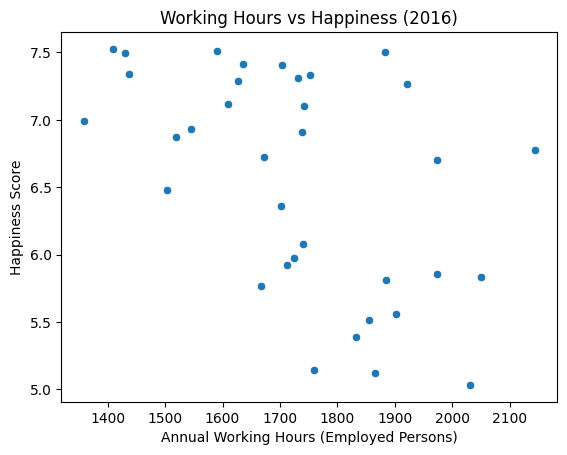

In [131]:
# making a scatter plot
sb.scatterplot(
    data=merged,
    x="Working_Hours",
    y="Happiness_Score"
)
plt.title("Working Hours vs Happiness (2016)")
plt.xlabel("Annual Working Hours (Employed Persons)")
plt.ylabel("Happiness Score")
plt.show()

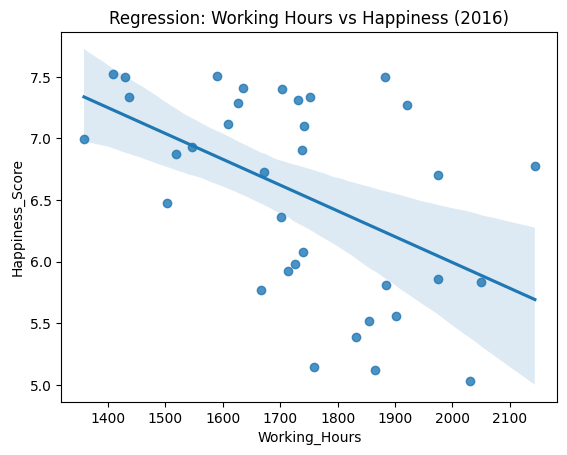

In [75]:
# simple regression line
sb.regplot(
    data=merged,
    x="Working_Hours",
    y="Happiness_Score"
)
plt.title("Regression: Working Hours vs Happiness (2016)")
plt.show()

In [76]:
# trying my hand at an OLS regression
X = merged["Working_Hours"]  # independent variable
y = merged["Happiness_Score"]  # dependent variable

# constant (intercept)
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Happiness_Score   R-squared:                       0.248
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     10.89
Date:                Wed, 17 Dec 2025   Prob (F-statistic):            0.00233
Time:                        17:16:04   Log-Likelihood:                -36.691
No. Observations:                  35   AIC:                             77.38
Df Residuals:                      33   BIC:                             80.49
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            10.1849      1.107      9.201      0.000       7.933      12.437
Working_Hours    -0.0021      0.001     -3.300      0.002      -0.003      -0.001
==============================================================================
Omnibus:                        3.359   Durbin-Watson:                   0.625
Prob(Omnibus):                  0.186   Jarque-Bera (JB):                1.522
Skew:                          -0.049   Prob(JB):                        0.467
Kurtosis:                       1.983   Cond. No.                     1.60e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.6e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

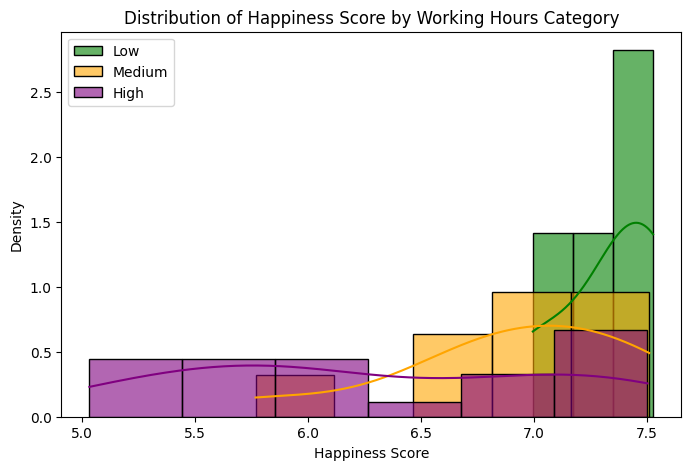

In [90]:
# working hours categories
merged['hours_category'] = pd.cut(
    merged['Working_Hours'],
    bins=[1200, 1500, 1700, 2200],  
    labels=['Low', 'Medium', 'High']
)

# plot overlaid histograms
plt.figure(figsize=(8,5))

sb.histplot(
    merged[merged['hours_category'] == 'Low']['Happiness_Score'],
    color='green',
    label='Low',
    kde=True,
    stat='density',
    alpha=0.6
)

sb.histplot(
    merged[merged['hours_category'] == 'Medium']['Happiness_Score'],
    color='orange',
    label='Medium',
    kde=True,
    stat='density',
    alpha=0.6
)

sb.histplot(
    merged[merged['hours_category'] == 'High']['Happiness_Score'],
    color='purple',
    label='High',
    kde=True,
    stat='density',
    alpha=0.6
)

plt.title('Distribution of Happiness Score by Working Hours Category')
plt.xlabel('Happiness Score')
plt.ylabel('Density')
plt.legend()
plt.show()

In [92]:
coef = model.params['Working_Hours']
pval = model.pvalues['Working_Hours']
r2 = model.rsquared

if pval < 0.05:
    significance = "statistically significant"
else:
    significance = "not statistically significant"

print(f"The slope coefficient for working hours is {coef:.3f}, which is {significance}.")
print(f"This means that for each additional working hour, happiness changes by about {coef:.4f} units on average.")
print(f"The R-squared of the model is {r2:.2f}, meaning the model explains {r2*100:.1f}% of the variance in happiness scores.")
print()
for cat in merged['hours_category'].unique():
    mean_val = merged[merged['hours_category']==cat]['Happiness_Score'].mean()
    print(f"Countries with {cat} working hours have an average happiness score of {mean_val:.2f}.")

The slope coefficient for working hours is -0.002, which is statistically significant.
This means that for each additional working hour, happiness changes by about -0.0021 units on average.
The R-squared of the model is 0.25, meaning the model explains 24.8% of the variance in happiness scores.

Countries with Low working hours have an average happiness score of 7.34.
Countries with Medium working hours have an average happiness score of 6.90.
Countries with High working hours have an average happiness score of 6.27.


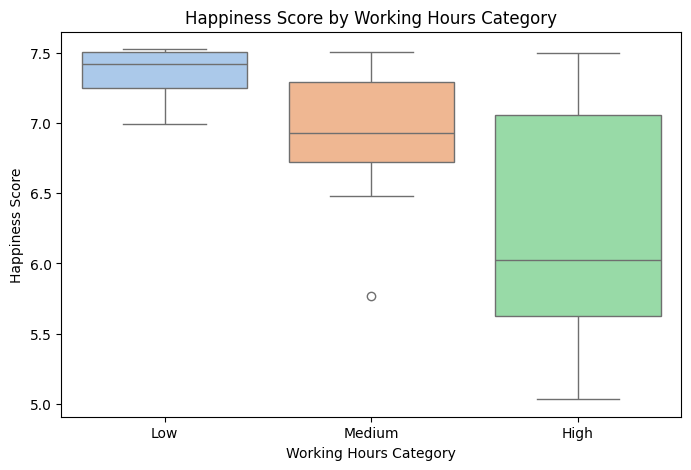

In [96]:
plt.figure(figsize=(8,5))
sb.boxplot(data=merged, x='hours_category', y='Happiness_Score', hue='hours_category', palette='pastel', legend=False)
plt.title('Happiness Score by Working Hours Category')
plt.xlabel('Working Hours Category')
plt.ylabel('Happiness Score')
plt.show()

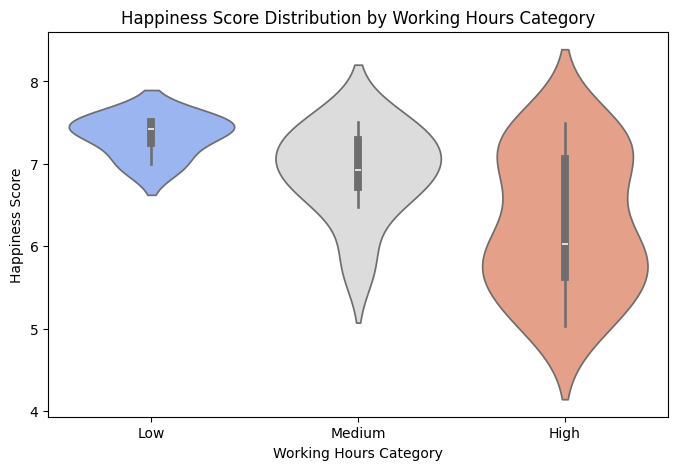

In [98]:
plt.figure(figsize=(8,5))
sb.violinplot(data=merged, x='hours_category', y='Happiness_Score', hue='hours_category', palette='coolwarm')
plt.title('Happiness Score Distribution by Working Hours Category')
plt.xlabel('Working Hours Category')
plt.ylabel('Happiness Score')
plt.show()

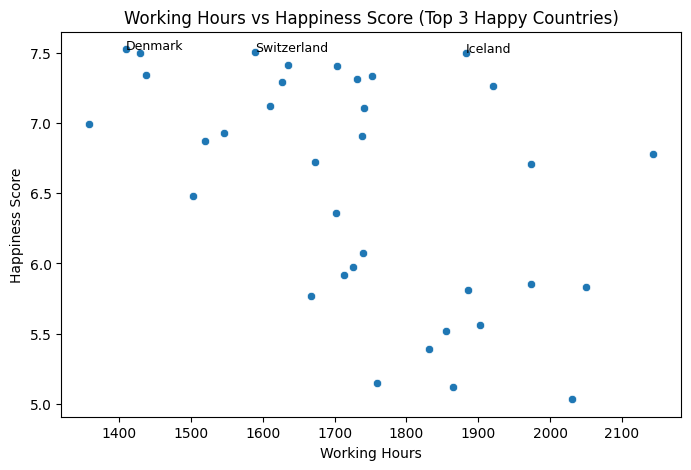

In [129]:
plt.figure(figsize=(8,5))
sb.scatterplot(data=merged, x='Working_Hours', y='Happiness_Score')
for i, row in merged.nlargest(3, 'Happiness_Score').iterrows():
    plt.text(row['Working_Hours'], row['Happiness_Score'], row['Country'], fontsize=9)
plt.title('Working Hours vs Happiness Score (Top 3 Happy Countries)')
plt.xlabel('Working Hours')
plt.ylabel('Happiness Score')
plt.show()

<Axes: xlabel='hours_category', ylabel='Happiness_Score'>

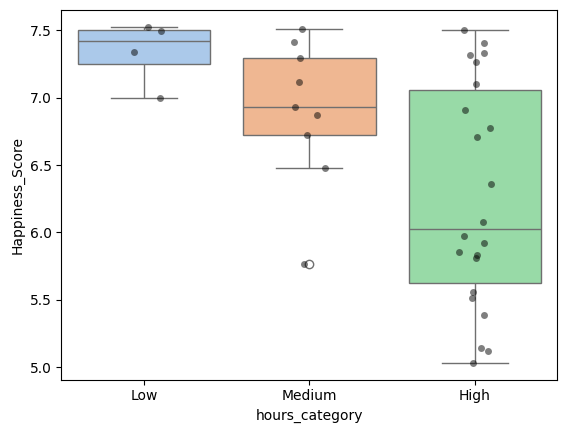

In [123]:
sb.boxplot(x='hours_category', y='Happiness_Score', data=merged, hue='hours_category', palette='pastel')
sb.stripplot(x='hours_category', y='Happiness_Score', data=merged, color='black', alpha=0.5)

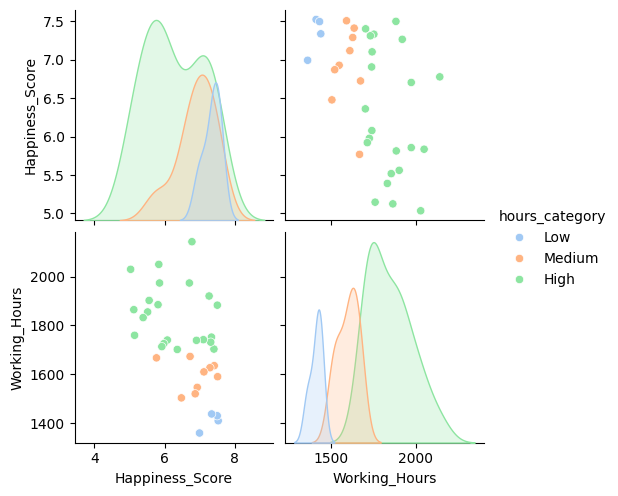

In [115]:
sb.pairplot(merged, vars=['Happiness_Score','Working_Hours'], hue='hours_category', palette='pastel')

In [112]:
import sys
!{sys.executable} -m pip install pyfiglet

  Using cached pyfiglet-1.0.4-py3-none-any.whl.metadata (7.4 kB)
Using cached pyfiglet-1.0.4-py3-none-any.whl (1.8 MB)


In [137]:
def generate_happiness_report(df, filename="happiness_2016_report.txt"):
    lines = []
    lines.append("="*60)
    lines.append("WORLD HAPPINESS & WORKING HOURS REPORT (2016)")
    lines.append("="*60)
    lines.append(f"Generated: {datetime.now().strftime('%B %d, %Y at %I:%M %p')}")
    lines.append(f"Countries analyzed: {len(df)}")
    lines.append("")

    lines.append("KEY FINDINGS")
    lines.append("-"*40)

    # means by category
    lines.append("\n1. Average Happiness by Working Hours Category:")
    for cat in df['hours_category'].unique():
        mean_val = df[df['hours_category']==cat]['Happiness_Score'].mean()
        lines.append(f"   - {cat}: {mean_val:.2f}")

    # top 5 happiest countries
    lines.append("\n2. Top 5 Happiest Countries:")
    top5 = df.sort_values('Happiness_Score', ascending=False).head(5)
    for i, row in enumerate(top5.itertuples(), 1):
        lines.append(f"   {i}. {row.Country}: {row.Happiness_Score:.2f}")

    # regression summary
    lines.append("\n3. Regression Summary:")
    lines.append(f"   - Working hours coefficient: {coef:.4f}")
    lines.append(f"   - R-squared: {r2:.2f}")

    lines.append("\n" + "="*60)
    lines.append("END OF REPORT")

    report = "\n".join(lines)
    print(report)

    with open(filename, "w") as f:
        f.write(report)

    print(f"\n✓ Report saved as {filename}")
    return report

# generate report
report = generate_happiness_report(merged)

WORLD HAPPINESS & WORKING HOURS REPORT (2016)
Generated: December 17, 2025 at 07:33 PM
Countries analyzed: 35

KEY FINDINGS
----------------------------------------

1. Average Happiness by Working Hours Category:
   - Low: 7.34
   - Medium: 6.90
   - High: 6.27

2. Top 5 Happiest Countries:
   1. Denmark: 7.53
   2. Switzerland: 7.51
   3. Iceland: 7.50
   4. Norway: 7.50
   5. Finland: 7.41

3. Regression Summary:
   - Working hours coefficient: -0.0021
   - R-squared: 0.25

END OF REPORT

✓ Report saved as happiness_2016_report.txt


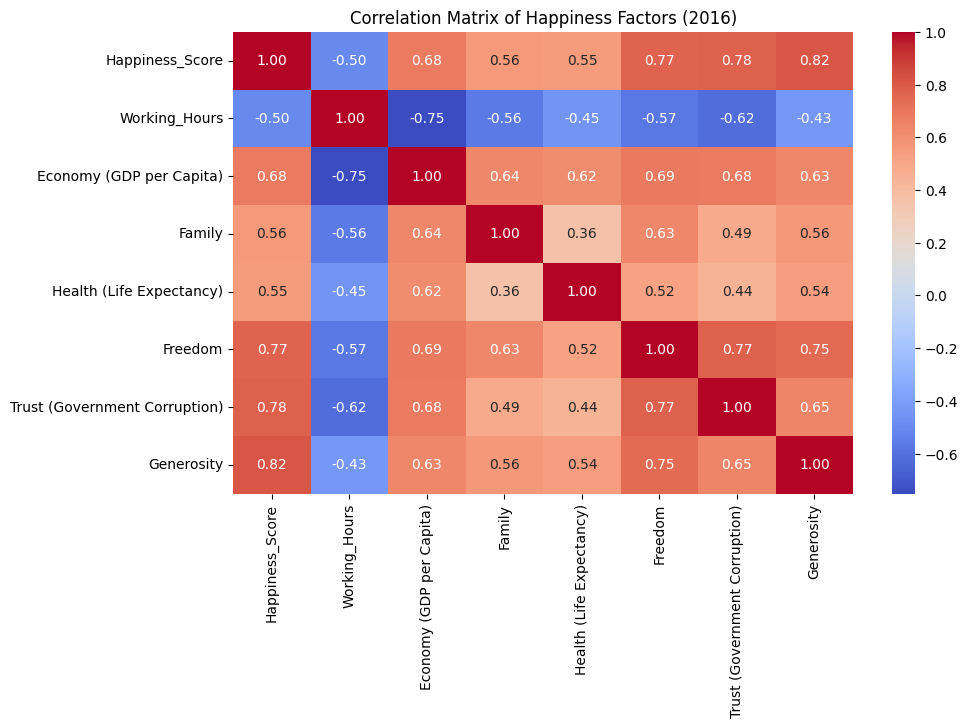

In [139]:
plt.figure(figsize=(10,6))

corr = merged[[
    'Happiness_Score',
    'Working_Hours',
    'Economy (GDP per Capita)',
    'Family',
    'Health (Life Expectancy)',
    'Freedom',
    'Trust (Government Corruption)',
    'Generosity'
]].corr()

sb.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix of Happiness Factors (2016)")
plt.show()

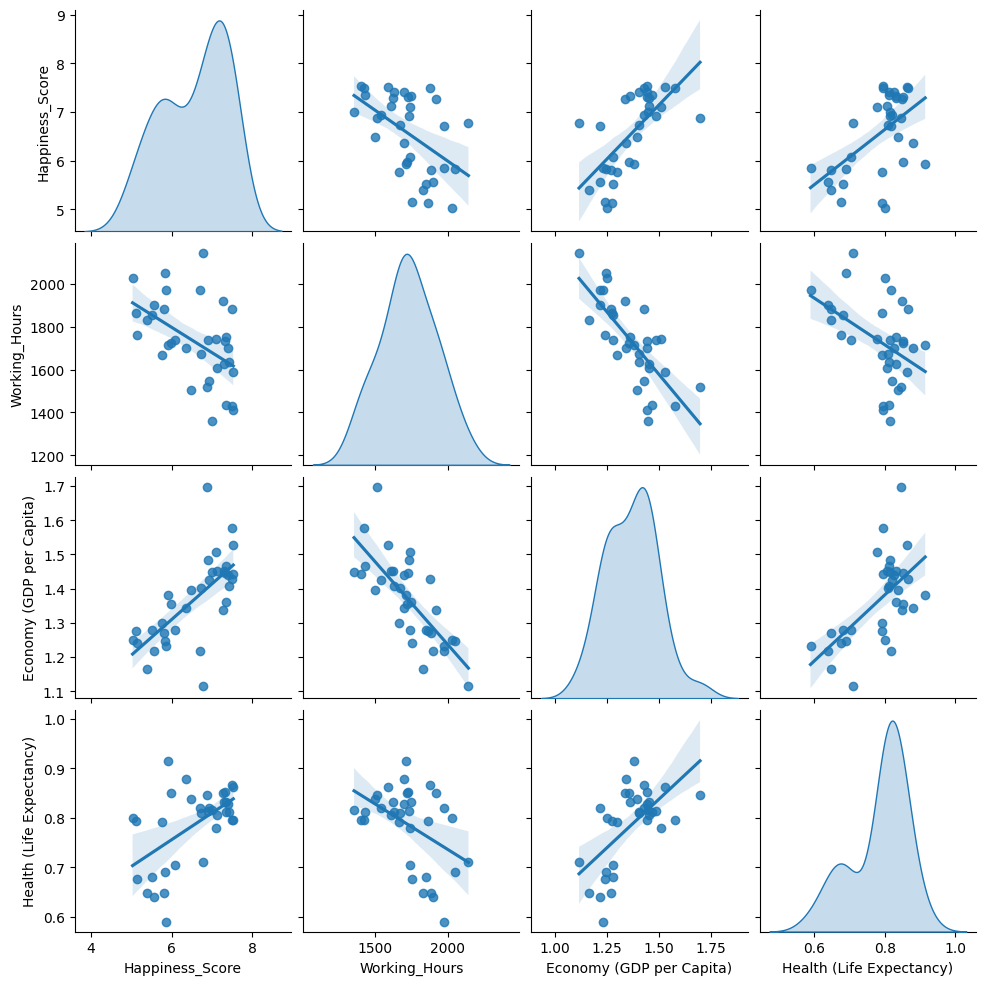

In [140]:
sb.pairplot(
    merged,
    vars=[
        'Happiness_Score',
        'Working_Hours',
        'Economy (GDP per Capita)',
        'Health (Life Expectancy)'
    ],
    kind='reg',
    diag_kind='kde'
)
plt.show()

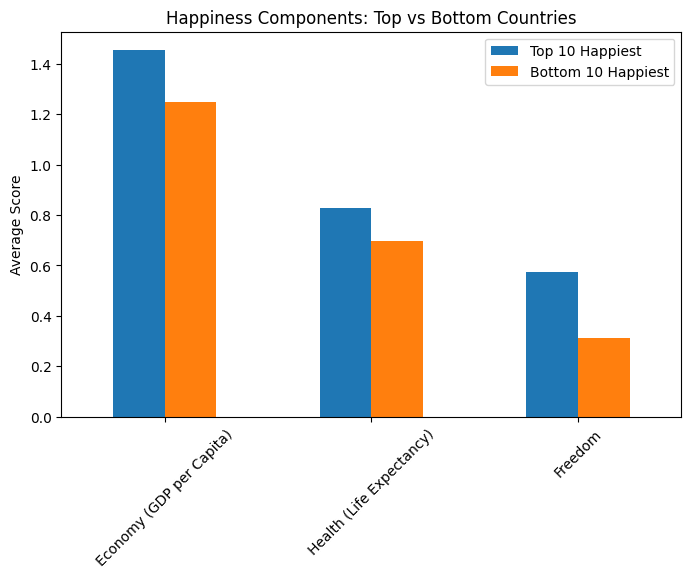

In [143]:
top = merged.sort_values('Happiness_Score', ascending=False).head(10)
bottom = merged.sort_values('Happiness_Score').head(10)

top_means = top[component_cols].mean()
bottom_means = bottom[component_cols].mean()

comparison = pd.DataFrame({
    'Top 10 Happiest': top_means,
    'Bottom 10 Happiest': bottom_means
})

comparison.plot(kind='bar', figsize=(8,5))
plt.title("Happiness Components: Top vs Bottom Countries")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.show()

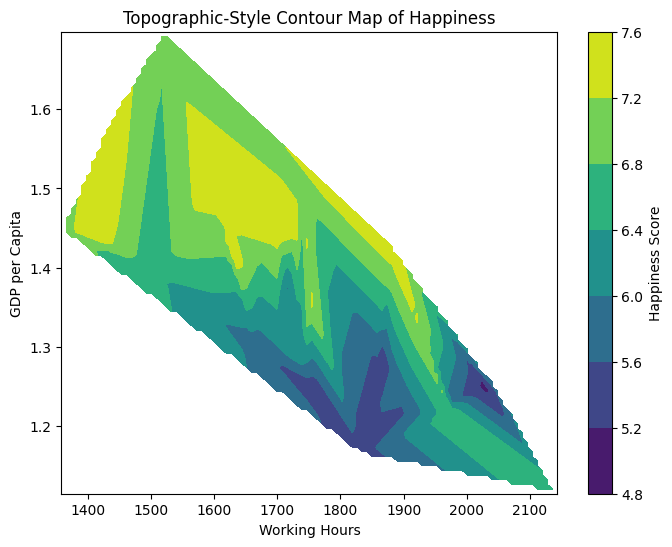

In [144]:
#  creating a grid
x = merged['Working_Hours']
y = merged['Economy (GDP per Capita)']
z = merged['Happiness_Score']

# creating a mesh mesh
xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 100)
xi, yi = np.meshgrid(xi, yi)

# interpolating
from scipy.interpolate import griddata
zi = griddata((x, y), z, (xi, yi), method='linear')

# plot contouring
plt.figure(figsize=(8,6))
contour = plt.contourf(xi, yi, zi, cmap='viridis')
plt.colorbar(contour, label='Happiness Score')
plt.xlabel('Working Hours')
plt.ylabel('GDP per Capita')
plt.title('Topographic-Style Contour Map of Happiness')
plt.show()

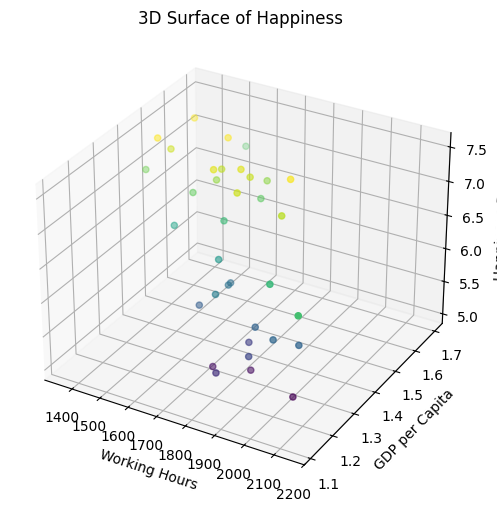

In [145]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    merged['Working_Hours'],
    merged['Economy (GDP per Capita)'],
    merged['Happiness_Score'],
    c=merged['Happiness_Score'],
    cmap='viridis'
)

ax.set_xlabel('Working Hours')
ax.set_ylabel('GDP per Capita')
ax.set_zlabel('Happiness Score')
ax.set_title('3D Surface of Happiness')

plt.show()

In [148]:
from datetime import datetime
from pyfiglet import figlet_format

print(figlet_format("Happy Birthday!", font="slant"))

print("""
╔═══════════════════════════════════╗
🎂      HAPPY BIRTHDAY TO ME!      🎂
🎉 Celebrating with Python & Data! 🎉
╚═══════════════════════════════════╝
""")

from datetime import date

today = date.today()

# just for fun: printing a birthday message on presentation day
if today.month == 12 and today.day == 18:  # replace with your birthday
    print("🎉 Happy Birthday to ME Number Three! I wanted to include this really badly! 🎉")

    __  __                       
   / / / /___ _____  ____  __  __
  / /_/ / __ `/ __ \/ __ \/ / / /
 / __  / /_/ / /_/ / /_/ / /_/ / 
/_/ /_/\__,_/ .___/ .___/\__, /  
           /_/   /_/    /____/   
    ____  _      __  __        __            __
   / __ )(_)____/ /_/ /_  ____/ /___ ___  __/ /
  / __  / / ___/ __/ __ \/ __  / __ `/ / / / / 
 / /_/ / / /  / /_/ / / / /_/ / /_/ / /_/ /_/  
/_____/_/_/   \__/_/ /_/\__,_/\__,_/\__, (_)   
                                   /____/      


╔═══════════════════════════════════╗
🎂      HAPPY BIRTHDAY TO ME!      🎂
🎉 Celebrating with Python & Data! 🎉
╚═══════════════════════════════════╝

